# SMOTE: Synthetic Minority Over-sampling Technique

## What is SMOTE?

**Simple definition:** SMOTE creates **brand new, synthetic** examples of your minority class instead of just duplicating existing ones.

**Analogy:** You have 10 real skulls. Instead of photocopying them (random oversampling), you study their features and create 90 NEW skulls that look similar but are slightly different. Like an artist drawing variations of a skull!

---

## Why SMOTE > Random Oversampling?

| Random Oversampling | SMOTE |
|--------------------|-------|
| Duplicates exact copies | Creates NEW unique samples |
| Model memorizes copies | Model learns general patterns |
| High overfitting risk | Lower overfitting risk |
| No variety | Adds diversity |
| "Photocopy machine" | "Creative artist" |

---

## How SMOTE Works (Step-by-Step)

### Step 1: Pick a minority sample

    Choose skull A from your minority class:
    💀 A


### Step 2: Find its nearest minority neighbors

    Find 5 nearest skulls to A:
    💀 A ←→ 💀 B, 💀 C, 💀 D, 💀 E, 💀 F


### Step 3: Draw line between A and a random neighbor

    Pick neighbor B:
    💀 A ------------------- 💀 B


### Step 4: Create NEW sample somewhere on that line

    💀 A ------●------ 💀 B
               |
               ▼
    💀 NEW (synthetic skull) 

    instead of make make many points on that line 


### Step 5: Repeat until balanced

    Do this hundreds of times → 100 unique synthetic skulls!


--- 

## Advantages of SMOTE ✅

| Advantage | Why It Matters |
|-----------|----------------|
| **No exact duplicates** | Model can't just memorize |
| **Adds diversity** | Creates realistic variations |
| **Reduces overfitting** | Compared to random oversampling |
| **No information loss** | Keeps all original data |
| **Works with small minority** | Can create many from few |
| **Improves generalization** | Model sees varied examples |

---

## Disadvantages of SMOTE ❌

| Disadvantage | Why It Hurts |
|--------------|--------------|
| **Can create unrealistic samples** | Synthetic samples might not make sense in real world |
| **Slow on large datasets** | Calculating neighbors takes time |
| **Assumes linearity** | Assumes samples between real ones are valid (not always true) |
| **Doesn't work for categorical data** | Can't average categories (cat + dog = ?) |
| **Amplifies noise** | If original data has errors, SMOTE spreads them |
| **Memory intensive** | Creates large datasets |

---


---

## SMOTE Pipeline (How You'll Use It)

```python
# Conceptual code (future reference)
from imblearn.over_sampling import SMOTE

"""
:

X → features (numbers that describe data)
y → labels (what we are trying to predict)

| feature1 | feature2 | target |
| -------- | -------- | ------ |
| 45       | 32       | 0      |
| 60       | 28       | 1      |

	28	1

👉 target = what we want to predict

"""

# Step 1: Split data FIRST (important!)
X = df.drop("target", axis=1) # from datafram drop target col and store the reset in x
y = df["target"]  # store target in Y

# Step 2: Apply SMOTE ONLY to training data

smote = SMOTE(random_state = 42, k_neighbors = 5)  # creating a SMOTE algorithm instance
 # 👉 SMOTE looks at 5 nearest neighbors
 # For each minority point → find 5 closest minority points

X_resampled, y_resampled = smote.fit_resample(X, y) # IT TAKES X,Y AS INPT AND RETURED X AND Y IN WHICH DATA IS ADDED USING SMOTE 

# fit -> Find minority samples
# resample -> 👉 Now SMOTE generates new data

"""
It is doing 3 things at once:

-> Step A: Read data

X = features (input data)
y = labels (0 / 1)


-> Step B: Learn structure
SMOTE:
finds minority points in y
analyzes their positions in X

-. Step C: Generate new dataset

It returns:
new X (features including synthetic rows)
new y (labels aligned with new X)

#####################################
MATHEMATICAL DRY RUN
#######################################


 x = [
  (50, 30),
  (60, 40),
  (10, 5),
]

y = [0, 0, 1]


-->> STEP 1: SMOTE splits classes internally

Majority:
0 → (50,30), (60,40)

Minority:
1 → (10,5)


-->> STEP 2: Find neighbors of minority

For (10,5):

finds closest points in minority class
(only itself in small example, but real case has many)


--->> STEP 3: Generate synthetic point

Formula:

    new = A + random * (B - A)

Example:

Assume:

A = (10,5)
B = (50,30)
random = 0.5

new = (10,5) + 0.5 * (40,25)
    = (10,5) + (20,12.5)
    = (30,17.5)

-->> STEP 4: Add synthetic sample

Now dataset becomes:

(50,30) → 0
(60,40) → 0
(10,5)  → 1
(30,17.5) → 1   ← NEW

---> STEP 5: Return updated X and y

X_resampled:
[
 (50,30),
 (60,40),
 (10,5),
 (30,17.5)
]

y_resampled:
[0, 0, 1, 1]

"""



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ---------------------------
# STEP 1: Create dataset
# ---------------------------
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "feature1": np.random.normal(50, 10, n),
    "feature2": np.random.normal(30, 5, n)
})

# Imbalanced target
df["target"] = [0]*900 + [1]*100

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["target"].value_counts())

# ---------------------------
# STEP 2: Split X and y
# ---------------------------
X = df.drop("target", axis=1)
y = df["target"]

# ---------------------------
# STEP 3: Apply SMOTE
# ---------------------------
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# ---------------------------
# STEP 4: Convert back to DataFrame
# ---------------------------
df_smote = pd.DataFrame(X_resampled, columns=X.columns)
df_smote["target"] = y_resampled

print(df_smote["target"].value_counts())

target
0    900
1    100
Name: count, dtype: int64
target
0    900
1    900
Name: count, dtype: int64


# EXAMPLE 2

In [9]:
np.random.seed(42)

n = 2000

df = pd.DataFrame({
    "income": np.random.normal(50000, 15000, n),
    "credit_score": np.random.normal(650, 70, n),
    "loan_amount": np.random.normal(20000, 8000, n),
    "age": np.random.normal(35, 10, n),
    "debt_ratio": np.random.uniform(0.1, 0.9, n)
})

df["default"] = [0]*1850 + [1]*150

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["default"].value_counts())
print()
print(df)

default
0    1850
1     150
Name: count, dtype: int64

            income  credit_score   loan_amount        age  debt_ratio  default
0     47985.368878    618.363544  29947.246377  55.541938    0.623445        1
1     47600.922051    554.383100   6616.848790  42.344767    0.210183        0
2     72360.892053    690.184985  29546.488047  48.954341    0.446461        0
3     50696.548222    702.540542  27425.965531  37.875639    0.670423        0
4     17706.641106    629.837279  27283.347997  34.844369    0.480234        0
...            ...           ...           ...        ...         ...      ...
1995  54820.358232    643.753609  23488.046202  34.256547    0.219915        0
1996  51227.440378    565.508485  30581.955735  36.222430    0.753999        0
1997  53043.845313    612.814999  16193.636448  26.741672    0.526424        0
1998  60097.720269    567.984196  18372.310871  21.520042    0.624982        0
1999  54539.531979    516.345074  17810.165983  35.230807    0.639359       

In [12]:
#### smote

#1. split data

x = df.drop("default", axis=1)
y = df["default"]

#2. Apply SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)

X_resampled, y_resampled = smote.fit_resample(x,y)

#3. Convert BAck to DAtaFrame 
df_smote = pd.DataFrame(X_resampled, columns=x.columns)
df_smote["default"] = y_resampled

# checking
print("Before SMOTE:")
print(df["default"].value_counts())

print("\nAfter SMOTE:")
print(df_smote["default"].value_counts())



Before SMOTE:
default
0    1850
1     150
Name: count, dtype: int64

After SMOTE:
default
1    1850
0    1850
Name: count, dtype: int64


# Exampple 3

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

np.random.seed(42)

# Majority class (safe customers)
safe_1 = np.random.multivariate_normal([50, 30], [[50, 10],[10, 30]], 900)
safe_2 = np.random.multivariate_normal([70, 60], [[40, 5],[5, 20]], 700)

# Minority class (risky customers)
risky = np.random.multivariate_normal([30, 70], [[20, -5],[-5, 25]], 150)

# Combine
X = np.vstack([safe_1, safe_2, risky])
y = np.array([0]*1600 + [1]*150)

df = pd.DataFrame(X, columns=["income", "risk_score"])
df["target"] = y

df

,income,risk_score,target
0,46.892381,27.951771,0
1,42.633225,35.331388,0
2,52.047405,29.559365,0
3,37.771060,29.158593,0
4,52.135695,33.870902,0
...,...,...,...
1745,30.164522,68.064185,1
1746,26.744856,71.079801,1
1747,35.343953,76.489664,1
1748,27.559488,73.572694,1


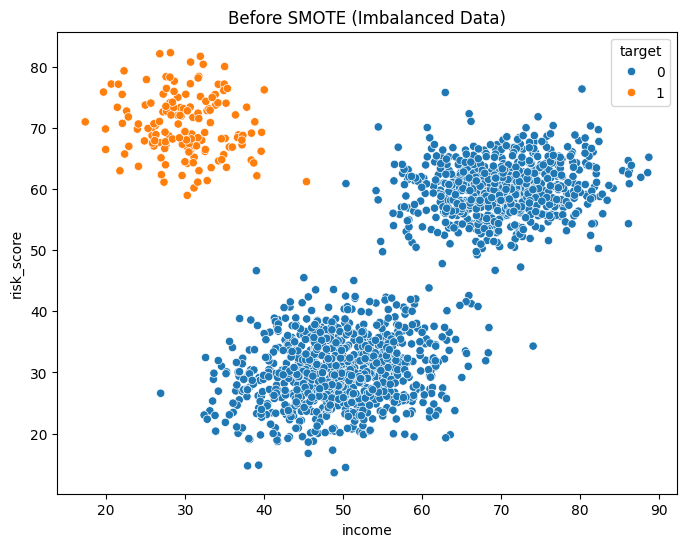

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="income",y="risk_score", hue="target")
plt.title("Before SMOTE (Imbalanced Data)")
plt.show()

In [ ]:

#1. split DAta
x_features = df.drop("target", axis=1)
y_labels = df["target"]

#apply smote
smote = SMOTE(k_neighbors=5, random_state=42)

X_resampled, y_resampled = smote.fit_resample(x_features,y_labels)

# make Dataframe 

df_smote = pd.DataFrame(X_resampled, columns=x_features.columns)
df_smote["target"] = y_resampled


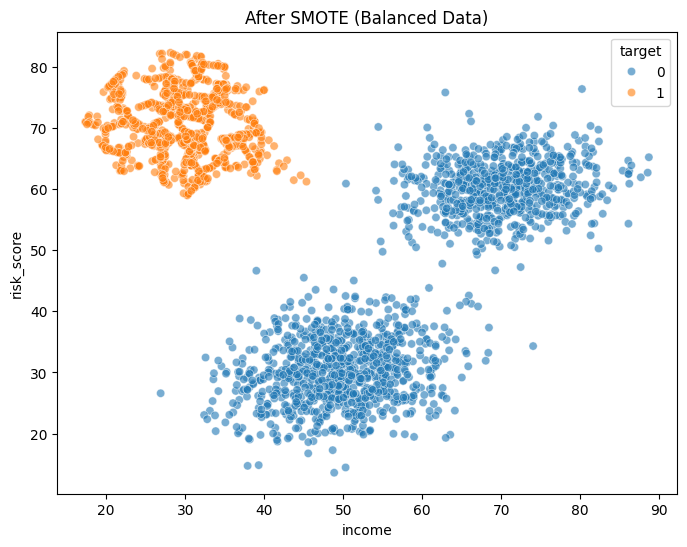

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_smote,
    x="income",
    y="risk_score",
    hue="target",
    alpha=0.6
)

plt.title("After SMOTE (Balanced Data)")
plt.show()

In [19]:
print("Before SMOTE:")
print(df.groupby("target").mean())

print("\nAfter SMOTE:")
print(df_smote.groupby("target").mean())

Before SMOTE:
           income  risk_score
target                       
0       58.658294   43.281211
1       30.021491   70.422302

After SMOTE:
           income  risk_score
target                       
0       58.658294   43.281211
1       30.054450   70.363674


# Example 4

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

np.random.seed(42)

# -----------------------------
# LOYAL NINJAS (Multiple clusters)
# -----------------------------
leaf_elite = np.random.multivariate_normal(
    mean=[80, 70],
    cov=[[50, 10], [10, 40]],
    size=800
)

anbu = np.random.multivariate_normal(
    mean=[70, 85],
    cov=[[40, -5], [-5, 30]],
    size=500
)

genin = np.random.multivariate_normal(
    mean=[50, 50],
    cov=[[60, 15], [15, 60]],
    size=400
)

# -----------------------------
# ROGUE NINJAS (Minority but structured)
# -----------------------------
rogue_akatsuki = np.random.multivariate_normal(
    mean=[30, 90],
    cov=[[30, -10], [-10, 50]],
    size=120
)

rogue_missing = np.random.multivariate_normal(
    mean=[20, 60],
    cov=[[25, 5], [5, 25]],
    size=80
)

# -----------------------------
# Combine everything
# -----------------------------
X = np.vstack([
    leaf_elite,
    anbu,
    genin,
    rogue_akatsuki,
    rogue_missing
])

y = np.array(
    [0]*1700 +   # loyal
    [1]*200      # rogue
)

df = pd.DataFrame(X, columns=["power_level", "loyalty_score"])
df["target"] = y

df

,power_level,loyalty_score,target
0,77.255711,67.358693,0
1,71.213915,74.982082,0
2,82.208789,69.764431,0
3,67.584717,67.573494,0
4,81.334528,74.533991,0
...,...,...,...
1895,19.033957,56.425623,1
1896,19.764923,58.242823,1
1897,20.999153,58.939808,1
1898,19.965769,61.307166,1


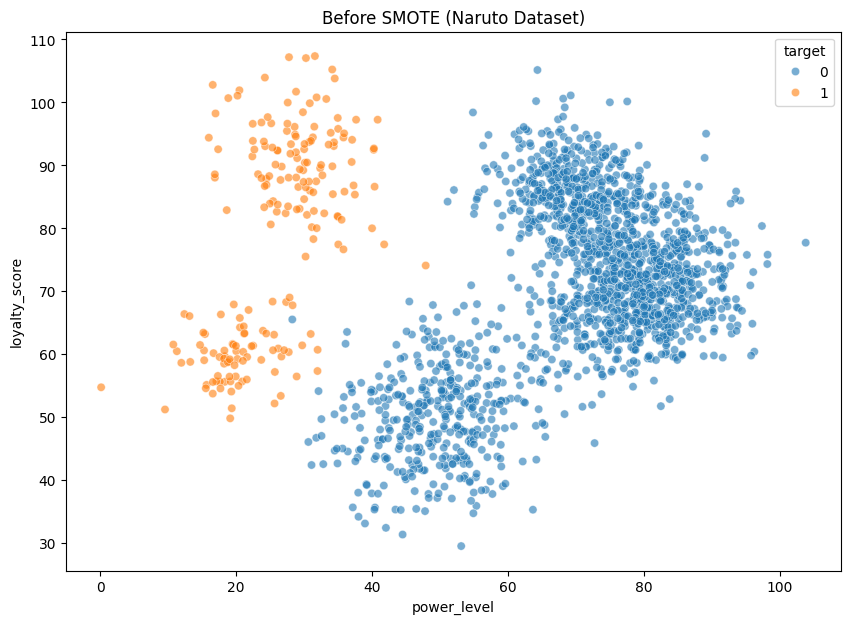

In [26]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="power_level",
    y="loyalty_score",
    hue="target",
    alpha=0.6
)

plt.title("Before SMOTE (Naruto Dataset)")
plt.show()

In [27]:

#1. Split Data
x_features = df.drop("target", axis=1)
y_labels = df["target"]

# 2. Apply SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)

X_resampled, y_resampled =smote.fit_resample(x_features, y_labels)

#3. COnstruct DF from Resampled Data

df_smote = pd.DataFrame(X_resampled, columns=x_features.columns)
df_smote["target"] = y_resampled


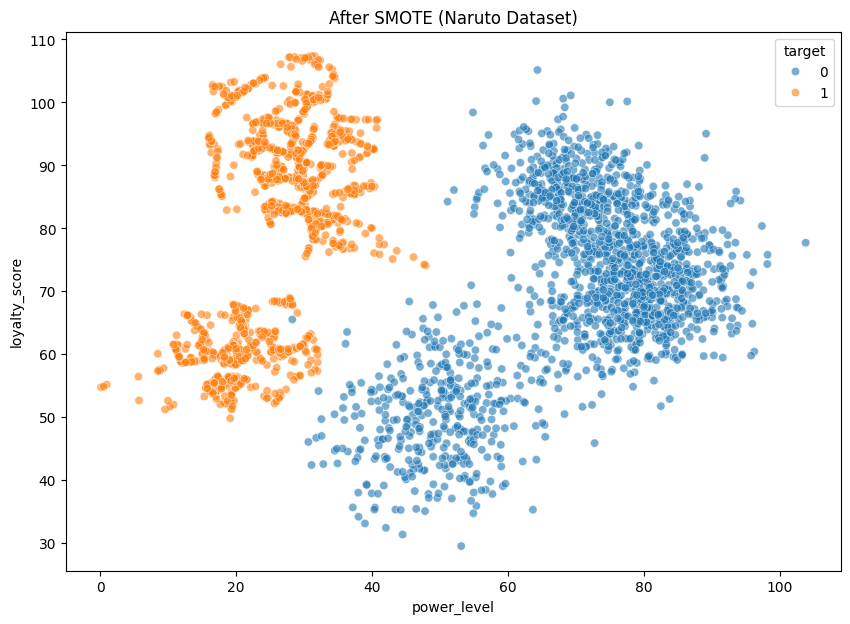

In [28]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_smote,
    x="power_level",
    y="loyalty_score",
    hue="target",
    alpha=0.6
)

plt.title("After SMOTE (Naruto Dataset)")
plt.show()

In [29]:
print("Before SMOTE:\n")
print(df.groupby("target").mean())

print("\nAfter SMOTE:\n")
print(df_smote.groupby("target").mean())

Before SMOTE:

        power_level  loyalty_score
target                            
0         69.921857      69.886879
1         25.755727      78.301892

After SMOTE:

        power_level  loyalty_score
target                            
0         69.921857      69.886879
1         25.256058      77.788815


# Example 

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

np.random.seed(42)

n = 5000  # LARGE dataset

df = pd.DataFrame({
    "usage_hours": np.random.gamma(2, 20, n),
    "login_frequency": np.random.poisson(10, n),
    "session_time": np.random.normal(30, 10, n),
    "purchase_amount": np.random.exponential(200, n),
    "support_calls": np.random.poisson(2, n),
    "account_age": np.random.randint(1, 60, n),
    "engagement_score": np.random.uniform(0, 100, n)
})

df["churn"] = [0]*4500 + [1]*500

df = df.sample(frac=1 , random_state=42).reset_index(drop=True)

df

,usage_hours,login_frequency,session_time,purchase_amount,support_calls,account_age,engagement_score,churn
0,44.351366,13,21.398412,520.545941,0,17,9.030426,0
1,16.713191,11,25.342466,193.090136,3,51,51.858926,0
2,6.774576,12,31.936283,386.690745,2,26,32.894634,0
3,45.525149,11,27.130824,220.778061,3,32,98.518126,0
4,39.741364,4,41.184694,166.699879,2,55,82.354565,0
...,...,...,...,...,...,...,...,...
4995,89.096742,13,21.867407,73.776030,5,29,69.210477,0
4996,35.503354,12,28.124961,3.452547,4,1,83.235028,0
4997,17.411598,7,27.892895,281.315086,2,4,88.479344,0
4998,56.663922,14,22.481433,222.168639,1,40,47.225608,0


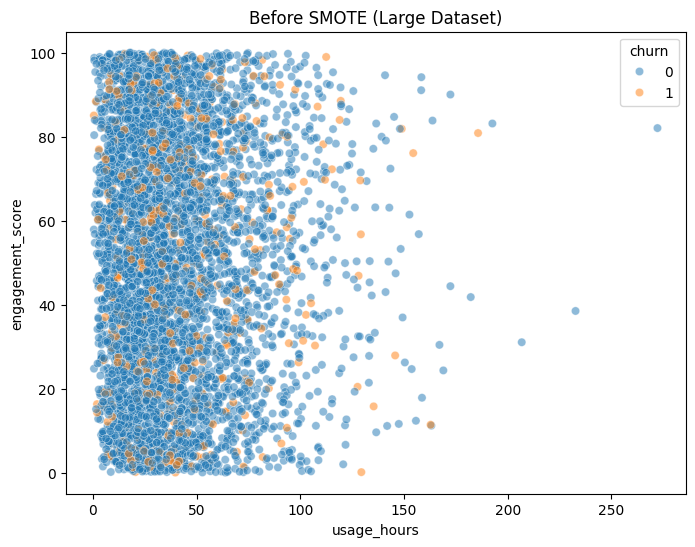

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="usage_hours",
    y="engagement_score",
    hue="churn",
    alpha=0.5
)

plt.title("Before SMOTE (Large Dataset)")
plt.show()

In [34]:
#1. Split data into features and labels

x_features = df.drop("churn", axis = 1)
y_labels = df["churn"]

#2. Apply SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)

X_resampled, y_resampled = smote.fit_resample(x_features,y_labels)

#3. Contruct dataframe

df_smote = pd.DataFrame(X_resampled, columns=x_features.columns)
df_smote["churn"] = y_resampled

plt.figure(figsize=(8,6))

print(df_smote["churn"].value_counts())

churn
0    4500
1    4500
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

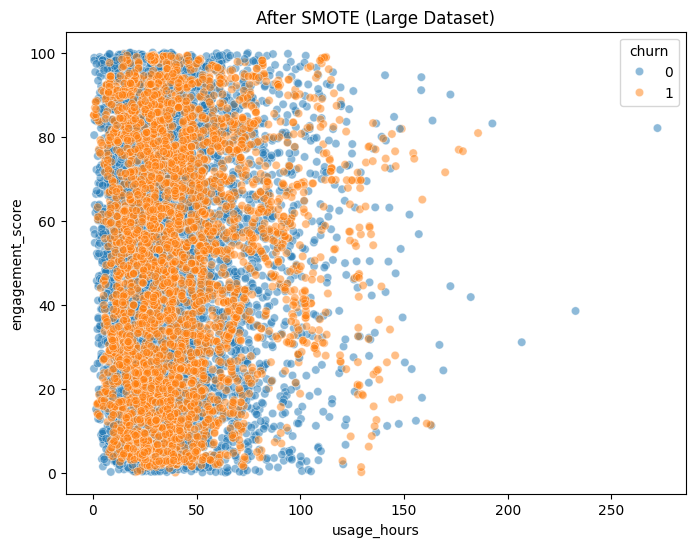

In [35]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_smote,
    x="usage_hours",
    y="engagement_score",
    hue="churn",
    alpha=0.5
)

plt.title("After SMOTE (Large Dataset)")
plt.show()

# Example 6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

np.random.seed(42)

n = 6000

df = pd.DataFrame({
    "transaction_amount": np.random.exponential(300, n),
    "transaction_frequency": np.random.poisson(5, n),
    "account_age": np.random.randint(1, 120, n),
    "device_trust_score": np.random.uniform(0, 1, n),
    "location_risk": np.random.uniform(0, 100, n),
    "failed_attempts": np.random.poisson(1, n)
})

# Introduce pattern (important!)
df["risk_score"] = (
    0.3 * df["transaction_amount"] +
    2 * df["failed_attempts"] +
    0.5 * df["location_risk"] -
    0.2 * df["device_trust_score"] * 100
)

# Imbalanced target based on risk
df["fraud"] = (df["risk_score"] > 250).astype(int)

print(df["fraud"].value_counts())


fraud
0    5521
1     479
Name: count, dtype: int64


In [37]:
df

,transaction_amount,transaction_frequency,account_age,device_trust_score,location_risk,failed_attempts,risk_score,fraud
0,140.780427,6,13,0.468604,42.873933,3,60.299012,0
1,903.036429,6,47,0.536616,61.937180,0,291.147195,1
2,395.023708,5,103,0.625434,21.147860,0,116.572353,0
3,273.882766,4,96,0.827215,13.409629,2,76.325342,0
4,50.887461,4,28,0.253043,94.445889,0,57.428332,0
...,...,...,...,...,...,...,...,...
5995,346.017522,7,46,0.845026,46.906297,0,110.357884,0
5996,209.882653,5,108,0.657189,50.382403,2,79.012216,0
5997,434.641011,9,4,0.446434,52.194804,0,147.561023,0
5998,199.245863,3,22,0.555980,6.925642,3,58.116975,0


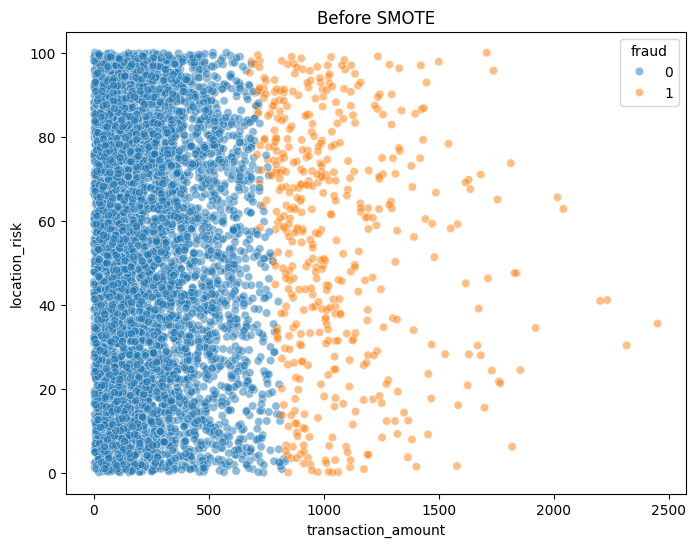

In [2]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="transaction_amount",
    y="location_risk",
    hue="fraud",
    alpha=0.5
)

plt.title("Before SMOTE")
plt.show()

In [9]:
#1. Split DAta Features and label

x_features = df.drop("fraud", axis= 1)
y_labels = df["fraud"]

#2. Apply Smote 

smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(x_features, y_labels)

# construct df
df_smote = pd.DataFrame(X_resampled, columns=x_features.columns)
df_smote["fraud"] = y_resampled



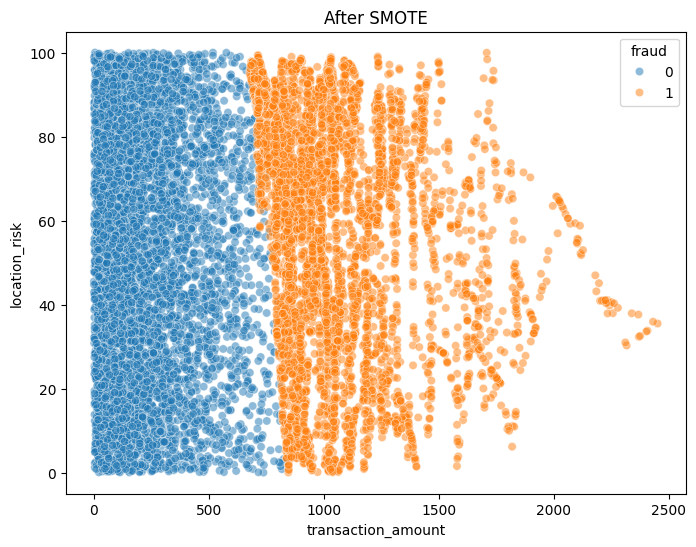

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_smote,
    x="transaction_amount",
    y="location_risk",
    hue="fraud",
    alpha=0.5
)

plt.title("After SMOTE")
plt.show()